In [1]:
# ============================================================
# Mount Google Drive
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# ============================================================
# Install Required Libraries
# ============================================================

!pip install -q librosa soundfile tensorflow tensorflow_hub tqdm

In [3]:
# ============================================================
# Imports
# ============================================================

import os
import random
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import librosa
import soundfile as sf

from tqdm import tqdm

from sklearn.model_selection import GroupShuffleSplit

import tensorflow as tf

import matplotlib.pyplot as plt

In [4]:
# ============================================================
# Set Random Seed
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Random seed set successfully.")

Random seed set successfully.


In [5]:
# ============================================================
# CHANGE THESE PATHS
# ============================================================

# Folder containing your windowed audio
DATASET_PATH = "/content/drive/MyDrive/Underwater Audio Data/processed"

# Folder where the deep learning dataset will be created
OUTPUT_PATH = "/content/drive/MyDrive/Underwater Audio Data/deep_learning_dataset"

In [6]:
CLASSES = [
    "Biological",
    "Vessels",
    "Ambience"
]

SAMPLE_RATE = 16000

WINDOW_SECONDS = 3

VALIDATION_SIZE = 0.15

TEST_SIZE = 0.15

# Verify Dataset

Check whether all class folders exist and count the number of audio files.

In [7]:
dataset_summary = {}

total_files = 0

for cls in CLASSES:

    folder = os.path.join(DATASET_PATH, cls)

    if not os.path.exists(folder):

        print(f"❌ Folder not found: {folder}")

        continue

    wav_files = list(Path(folder).rglob("*.wav"))

    dataset_summary[cls] = len(wav_files)

    total_files += len(wav_files)

print("Dataset Summary")

print(dataset_summary)

print()

print(f"Total Audio Files : {total_files}")

Dataset Summary
{'Biological': 540, 'Vessels': 4105, 'Ambience': 272}

Total Audio Files : 4917


In [8]:
summary_df = pd.DataFrame({

    "Class": dataset_summary.keys(),

    "Files": dataset_summary.values()

})

summary_df

,Class,Files
0,Biological,540
1,Vessels,4105
2,Ambience,272


# Scan Audio Files

This section scans every `.wav` file, extracts useful metadata, and prepares
a dataframe for splitting.

Each row represents **one audio chunk**.

In [9]:
# ============================================================
# Scan Dataset
# ============================================================

audio_data = []

for cls in CLASSES:

    class_folder = os.path.join(DATASET_PATH, cls)

    wav_files = sorted(Path(class_folder).rglob("*.wav"))

    print(f"{cls}: {len(wav_files)} files")

    for file in tqdm(wav_files):

        audio_data.append({
            "filepath": str(file),
            "filename": file.name,
            "class": cls
        })

print()

print("Finished scanning dataset.")

Biological: 540 files


100%|██████████| 540/540 [00:00<00:00, 222794.04it/s]


Vessels: 4105 files


100%|██████████| 4105/4105 [00:00<00:00, 574514.26it/s]


Ambience: 272 files


100%|██████████| 272/272 [00:00<00:00, 433124.79it/s]


Finished scanning dataset.


In [10]:
audio_df = pd.DataFrame(audio_data)

print(audio_df.head())

print()

print("Total files:", len(audio_df))

                                            filepath                filename  \
0  /content/drive/MyDrive/Underwater Audio Data/p...    Bluewhale_chunk0.wav   
1  /content/drive/MyDrive/Underwater Audio Data/p...    Bluewhale_chunk1.wav   
2  /content/drive/MyDrive/Underwater Audio Data/p...   Bluewhale_chunk10.wav   
3  /content/drive/MyDrive/Underwater Audio Data/p...  Bluewhale_chunk100.wav   
4  /content/drive/MyDrive/Underwater Audio Data/p...  Bluewhale_chunk101.wav   

        class  
0  Biological  
1  Biological  
2  Biological  
3  Biological  
4  Biological  

Total files: 4917


# Extract Recording IDs

We must identify which chunks belong to the same recording.

Example

recording01_chunk001.wav

↓

Recording ID

recording01

In [12]:
# ============================================================
# CHANGE THIS FUNCTION IF NEEDED
# ============================================================

def extract_recording_id(filename):

    # Example:
    #
    # bio_01_chunk_001.wav
    #
    # returns
    #
    # bio_01

    parts = filename.split("_chunk")

    return parts[0]

In [13]:
audio_df["recording_id"] = audio_df["filename"].apply(extract_recording_id)

audio_df.head()

,filepath,filename,class,recording_id
0,/content/drive/MyDrive/Underwater Audio Data/p...,Bluewhale_chunk0.wav,Biological,Bluewhale
1,/content/drive/MyDrive/Underwater Audio Data/p...,Bluewhale_chunk1.wav,Biological,Bluewhale
2,/content/drive/MyDrive/Underwater Audio Data/p...,Bluewhale_chunk10.wav,Biological,Bluewhale
3,/content/drive/MyDrive/Underwater Audio Data/p...,Bluewhale_chunk100.wav,Biological,Bluewhale
4,/content/drive/MyDrive/Underwater Audio Data/p...,Bluewhale_chunk101.wav,Biological,Bluewhale


In [14]:
print("Unique Recordings")

print(audio_df["recording_id"].nunique())

Unique Recordings
212


# Verify Chunk Distribution

Let's check how many chunks belong to each recording.

In [15]:
chunk_counts = (

    audio_df

    .groupby("recording_id")

    .size()

    .sort_values(ascending=False)

)

chunk_counts.head(20)

,0
recording_id,
large vessel,200
Tugboat_2,135
Passengership_18,135
Cargo_7,134
Tugboat_1,133
Cargo_12,133
Cargo_6,132
Cargo_4,132
Cargo_1,131


# Recording-Level Train/Test Split

Instead of splitting audio chunks randomly,
we split by recording.

This prevents data leakage.

In [16]:
from sklearn.model_selection import GroupShuffleSplit

splitter = GroupShuffleSplit(

    n_splits=1,

    test_size=TEST_SIZE,

    random_state=SEED

)

train_index, test_index = next(

    splitter.split(

        audio_df,

        groups=audio_df["recording_id"]

    )

)

train_df = audio_df.iloc[train_index]

test_df = audio_df.iloc[test_index]

In [17]:
print("Train Size")

print(len(train_df))

print()

print("Test Size")

print(len(test_df))

Train Size
4321

Test Size
596


# Create Validation Set

Split the training recordings again to create a validation set.

In [18]:
splitter = GroupShuffleSplit(

    n_splits=1,

    test_size=VALIDATION_SIZE,

    random_state=SEED

)

train_index, val_index = next(

    splitter.split(

        train_df,

        groups=train_df["recording_id"]

    )

)

validation_df = train_df.iloc[val_index]

train_df = train_df.iloc[train_index]

In [19]:
print()

print("Train")

print(len(train_df))

print()

print("Validation")

print(len(validation_df))

print()

print("Test")

print(len(test_df))


Train
3915

Validation
406

Test
596


# Verify No Data Leakage

No recording ID should appear in more than one split.

In [20]:
train_ids = set(train_df["recording_id"])

val_ids = set(validation_df["recording_id"])

test_ids = set(test_df["recording_id"])

print("Train-Val Overlap :", len(train_ids & val_ids))

print("Train-Test Overlap :", len(train_ids & test_ids))

print("Validation-Test Overlap :", len(val_ids & test_ids))

Train-Val Overlap : 0
Train-Test Overlap : 0
Validation-Test Overlap : 0


# Create Folder Structure

We will organize the dataset as follows:

deep_learning_dataset/

    train/

        Biological/

        Vessels/

        Ambience/

    validation/

        Biological/

        Vessels/

        Ambience/

    test/

        Biological/

        Vessels/

        Ambience/

This folder structure is compatible with TensorFlow/Keras and many other deep learning frameworks.

In [21]:
# ============================================================
# Create Output Directory
# ============================================================

os.makedirs(OUTPUT_PATH, exist_ok=True)

print("Output directory created.")

Output directory created.


# Save Metadata

We also save CSV files describing each split.

These are useful later for debugging and evaluation.

In [22]:
# ============================================================
# Save Split CSV Files
# ============================================================

train_csv = os.path.join(OUTPUT_PATH, "train.csv")
validation_csv = os.path.join(OUTPUT_PATH, "validation.csv")
test_csv = os.path.join(OUTPUT_PATH, "test.csv")

train_df.to_csv(train_csv, index=False)
validation_df.to_csv(validation_csv, index=False)
test_df.to_csv(test_csv, index=False)

print("CSV files saved successfully.")

print(f"Train CSV: {train_csv}")
print(f"Validation CSV: {validation_csv}")
print(f"Test CSV: {test_csv}")

CSV files saved successfully.
Train CSV: /content/drive/MyDrive/Underwater Audio Data/deep_learning_dataset/train.csv
Validation CSV: /content/drive/MyDrive/Underwater Audio Data/deep_learning_dataset/validation.csv
Test CSV: /content/drive/MyDrive/Underwater Audio Data/deep_learning_dataset/test.csv


In [23]:
print("=" * 50)
print("DATASET SUMMARY")
print("=" * 50)

print(f"Training Samples   : {len(train_df)}")
print(f"Validation Samples : {len(validation_df)}")
print(f"Testing Samples    : {len(test_df)}")

print()

print(f"Training Recordings   : {train_df['recording_id'].nunique()}")
print(f"Validation Recordings : {validation_df['recording_id'].nunique()}")
print(f"Testing Recordings    : {test_df['recording_id'].nunique()}")

DATASET SUMMARY
Training Samples   : 3915
Validation Samples : 406
Testing Samples    : 596

Training Recordings   : 153
Validation Recordings : 27
Testing Recordings    : 32


# Class Distribution

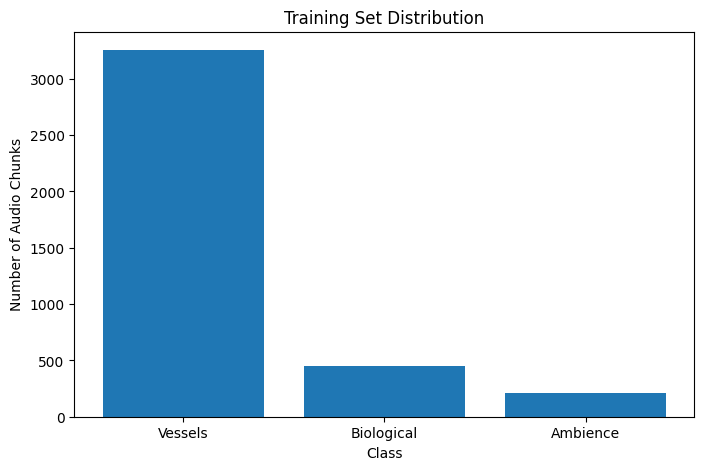

In [24]:
fig, ax = plt.subplots(figsize=(8,5))

train_counts = train_df["class"].value_counts()

ax.bar(
    train_counts.index,
    train_counts.values
)

ax.set_title("Training Set Distribution")

ax.set_xlabel("Class")

ax.set_ylabel("Number of Audio Chunks")

plt.show()

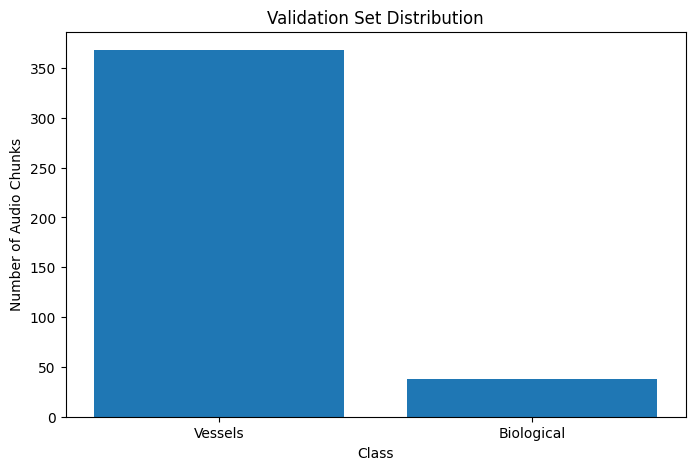

In [25]:
fig, ax = plt.subplots(figsize=(8,5))

val_counts = validation_df["class"].value_counts()

ax.bar(
    val_counts.index,
    val_counts.values
)

ax.set_title("Validation Set Distribution")

ax.set_xlabel("Class")

ax.set_ylabel("Number of Audio Chunks")

plt.show()

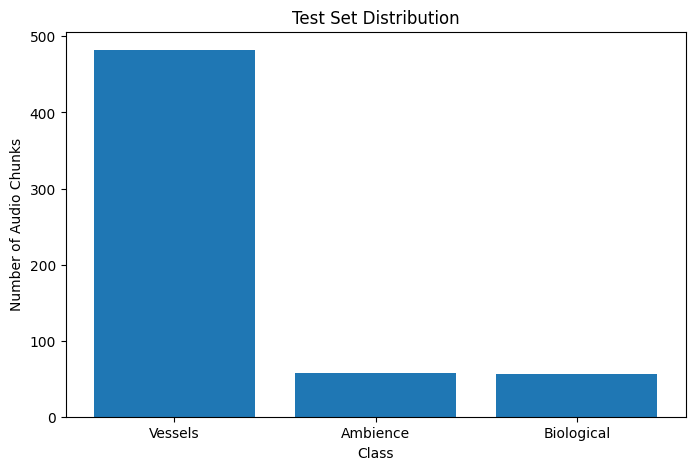

In [26]:
fig, ax = plt.subplots(figsize=(8,5))

test_counts = test_df["class"].value_counts()

ax.bar(
    test_counts.index,
    test_counts.values
)

ax.set_title("Test Set Distribution")

ax.set_xlabel("Class")

ax.set_ylabel("Number of Audio Chunks")

plt.show()

# Dataset Summary

In [27]:
summary = pd.DataFrame({
    "Split": ["Train", "Validation", "Test"],
    "Samples": [
        len(train_df),
        len(validation_df),
        len(test_df)
    ],
    "Unique Recordings": [
        train_df["recording_id"].nunique(),
        validation_df["recording_id"].nunique(),
        test_df["recording_id"].nunique()
    ]
})

summary

,Split,Samples,Unique Recordings
0,Train,3915,153
1,Validation,406,27
2,Test,596,32


In [28]:
# ============================================================
# Verify No Duplicate Filepaths
# ============================================================

train_paths = set(train_df["filepath"])
val_paths = set(validation_df["filepath"])
test_paths = set(test_df["filepath"])

print("Train ∩ Validation :", len(train_paths & val_paths))
print("Train ∩ Test       :", len(train_paths & test_paths))
print("Validation ∩ Test  :", len(val_paths & test_paths))

Train ∩ Validation : 0
Train ∩ Test       : 0
Validation ∩ Test  : 0
